Shape: (90189, 5)
   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Shape after cleaning: (90189, 5)
Missing values after cleaning:
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

 Churn rate: 0.814

Train size     : 63132
Validation size: 13528
Test size      : 13529

========== VALIDATION RESULTS ==========

--- Logistic Regression ---
ROC-AUC : 0.8876
              precision    recall  f1-score   support

    Retained       0.73      0.52      0.60      2517
     Churned       0.90      0.96     

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:18:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost ---
ROC-AUC : 0.8889
              precision    recall  f1-score   support

    Retained       0.49      0.80      0.61      2517
     Churned       0.95      0.81      0.87     11011

    accuracy                           0.81     13528
   macro avg       0.72      0.81      0.74     13528
weighted avg       0.86      0.81      0.82     13528


Best model on validation: XGBoost (AUC=0.8889)

========== FINAL TEST RESULTS ==========
Model          : XGBoost
ROC-AUC        : 0.8924
              precision    recall  f1-score   support

    Retained       0.50      0.81      0.62      2517
     Churned       0.95      0.81      0.88     11012

    accuracy                           0.81     13529
   macro avg       0.72      0.81      0.75     13529
weighted avg       0.86      0.81      0.83     13529



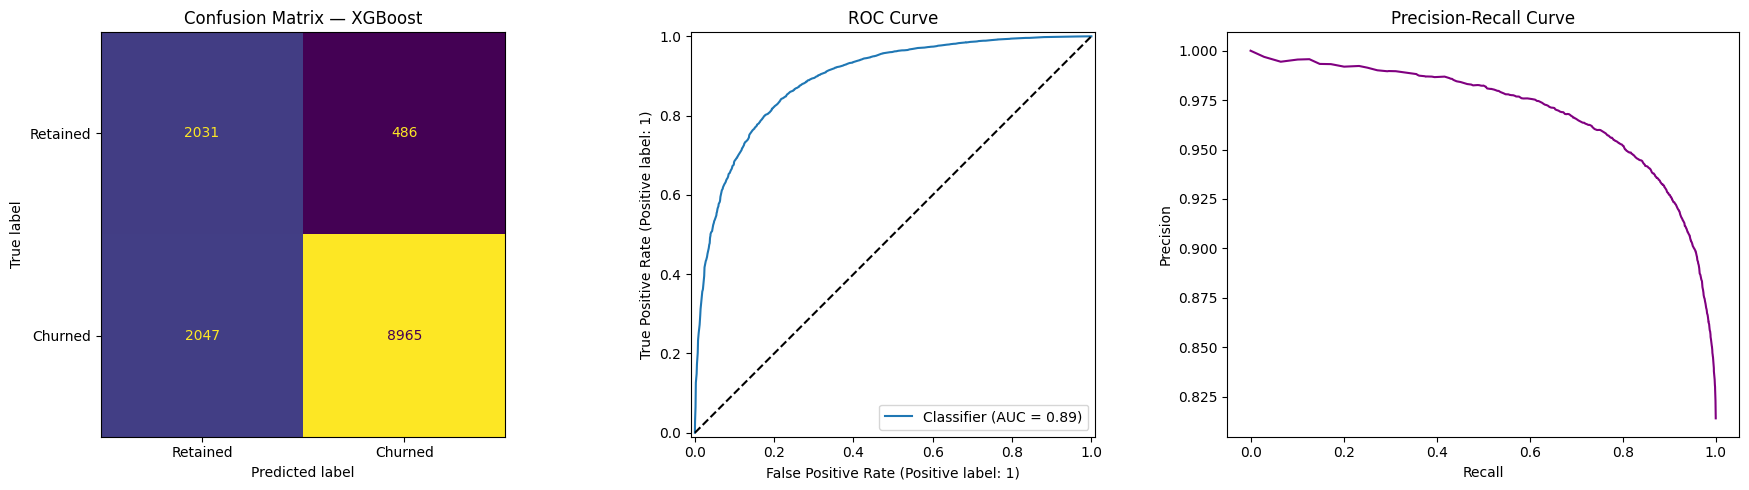

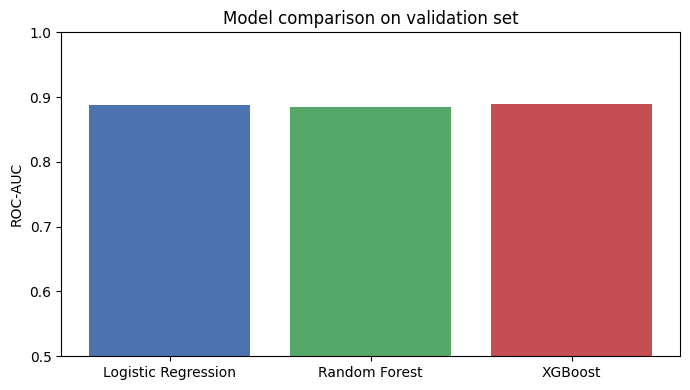

/tmp/ipykernel_5409/3747819263.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churned', y='sum_gamerounds',
/tmp/ipykernel_5409/3747819263.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Retained', 'Churned'])


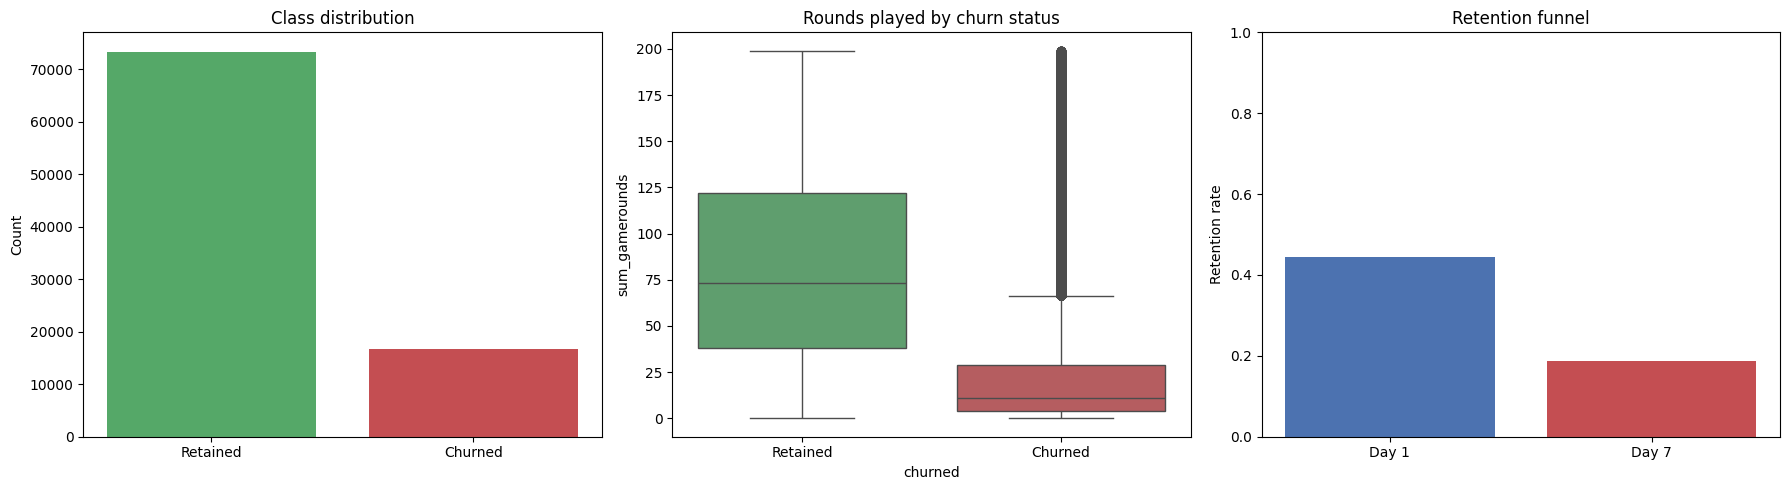


All plots saved.
Done.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, precision_recall_curve)

#  LOADING DATA
df = pd.read_csv('cookie_cats.csv')
print("Shape:", df.shape)
print(df.head())
print(df.isnull().sum())

#  DROP NaNs
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"\nShape after cleaning: {df.shape}")
print("Missing values after cleaning:")
print(df.isnull().sum())

#  DEFINITION OF CHURNED
df['churned'] = (df['retention_7'] == False).astype(int)
print("\n Churn rate:", df['churned'].mean().round(3))

# FEATURE ENGINEERING
df['log_rounds']      = np.log1p(df['sum_gamerounds'])
df['engagement_tier'] = pd.cut(df['sum_gamerounds'],
                                 bins=[0, 5 , 20,60, 200, float('inf')],
                                 labels=[0, 1, 2, 3, 4],
                                 include_lowest=True).astype(int)
df['retained_day1']   = df['retention_1'].astype(int)
df['engaged_early']   = ((df['sum_gamerounds'] > 5) &
                          (df['retention_1'] == True)).astype(int)
df['rounds_bucket']   = pd.qcut(df['sum_gamerounds'],
                                 q=4, labels=[0, 1, 2, 3]).astype(int)
df['gate']            = (df['version'] == 'gate_40').astype(int)

X = df[['log_rounds', 'engagement_tier', 'retained_day1',
         'engaged_early', 'rounds_bucket', 'gate']]
y = df['churned']

#  TRAIN / VALIDATION / TEST SPLIT
# 70% train | 15% validation | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nTrain size     : {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size      : {X_test.shape[0]}")

# TRAINING 3 MODELS
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(
                               scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                               n_estimators=200,
                               max_depth=5,
                               learning_rate=0.05,
                               use_label_encoder=False,
                               eval_metric='auc',
                               random_state=42
                           )
}

# Evaluate all 3 Models on validation set, to pick the best one
print("\n========== VALIDATION RESULTS ==========")
val_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_val_prob = model.predict_proba(X_val)[:, 1]
    y_val_pred = model.predict(X_val)
    auc = roc_auc_score(y_val, y_val_prob)
    val_scores[name] = auc
    print(f"\n--- {name} ---")
    print(f"ROC-AUC : {auc:.4f}")
    print(classification_report(y_val, y_val_pred,
                                 target_names=['Retained', 'Churned']))

best_model_name = max(val_scores, key=val_scores.get)
best_model      = models[best_model_name]
print(f"\nBest model on validation: {best_model_name} "
      f"(AUC={val_scores[best_model_name]:.4f})")

# FINAL EVALUATION ON TEST SET
print("\n========== FINAL TEST RESULTS ==========")
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

print(f"Model          : {best_model_name}")
print(f"ROC-AUC        : {roc_auc_score(y_test, y_test_prob):.4f}")
print(classification_report(y_test, y_test_pred,
                             target_names=['Retained', 'Churned']))

# Confusion matrix + ROC + Precision-Recall
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=['Retained', 'Churned'],
    ax=axes[0], colorbar=False
)
axes[0].set_title(f'Confusion Matrix — {best_model_name}')

RocCurveDisplay.from_predictions(y_test, y_test_prob, ax=axes[1])
axes[1].set_title('ROC Curve')
axes[1].plot([0, 1], [0, 1], 'k--')

precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
axes[2].plot(recall, precision, color='purple')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150)
plt.show()

# Validation comparison by bar chart
plt.figure(figsize=(7, 4))
plt.bar(val_scores.keys(), val_scores.values(),
        color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylim(0.5, 1.0)
plt.ylabel('ROC-AUC')
plt.title('Model comparison on validation set')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# For EDA PLOTS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

churn_counts = df['churned'].value_counts()
axes[0].bar(['Retained', 'Churned'], churn_counts.values,
             color=['#55A868', '#C44E52'])
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Count')

sns.boxplot(x='churned', y='sum_gamerounds',
            data=df[df['sum_gamerounds'] < 200],
            ax=axes[1], palette=['#55A868', '#C44E52'])
axes[1].set_xticklabels(['Retained', 'Churned'])
axes[1].set_title('Rounds played by churn status')

retention = {'Day 1': df['retention_1'].mean(),
             'Day 7': df['retention_7'].mean()}
axes[2].bar(retention.keys(), retention.values(),
            color=['#4C72B0', '#C44E52'])
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Retention rate')
axes[2].set_title('Retention funnel')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

print("\nAll plots saved.")
print("Done.")